# Импорт библиотек

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes, load_breast_cancer, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, recall_score, silhouette_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier as SkExtraTreesClassifier

from sklearn.cluster import KMeans, dbscan
from sklearn.mixture import GaussianMixture

from src.unsupervised import MyKMeans
from src.supervised import (
    MyLinearRegression, MyRidge, MyLasso,
    MyLogisticRegressionSGD, MyKNN, NB,
    MyDesisionTreeClassifier, MyDesisionTreeRegressor,
    MyRandomForestClassifier, MyGBDTClassifier, ExtraTreesClassifier,
)

RANDOM_STATE = 21

# Сравнение алгоритмов регрессии

<h3> Для тестирования алгоритмов регрессии был использован датасет в котором нужно по 10 показателям предсказать количественный признак прогрессирования заболевания через год после исходного уровня

## Загрузка и разделение датасета на тренировочную и тестовую выборки

In [10]:
data = load_diabetes()
X_df = pd.DataFrame(data.data, columns=data.feature_names)
y_s = pd.Series(data.target)

In [11]:

X_train_df, X_test_df, y_train_s, y_test_s = train_test_split(X_df, y_s, test_size=0.2, random_state=RANDOM_STATE)

X_train_np = X_train_df.values
X_test_np  = X_test_df.values
y_train_np = y_train_s.values
y_test_np  = y_test_s.values

## Функция для добавления результатов в таблицу

In [ ]:
reg_results = []

def reg_row(name, y_true, y_pred):
    reg_results.append({
        "Model": name,
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        "R2":   round(r2_score(y_true, y_pred), 4),
    })


## обучение всех классификаторов

In [13]:
# Linear Regression
my_lr = MyLinearRegression(epochs=1000)
my_lr.fit(X_train_np, y_train_s, solution='GD', learning_rate=0.1)
reg_row("MyLinearRegression (GD)", y_test_np, my_lr.predict(X_test_np))

sk_lr = LinearRegression().fit(X_train_np, y_train_np)
reg_row("sklearn LinearRegression", y_test_np, sk_lr.predict(X_test_np))

# Ridge
my_ridge = MyRidge(epochs=1000)
my_ridge.fit(X_train_np, y_train_s, lmb=1.0, solution='analytical')
reg_row("MyRidge (analytical)", y_test_np, my_ridge.predict(X_test_np))

sk_ridge = Ridge(alpha=1.0).fit(X_train_np, y_train_np)
reg_row("sklearn Ridge", y_test_np, sk_ridge.predict(X_test_np))

# Lasso
my_lasso = MyLasso(epochs=2000)
my_lasso.fit(X_train_np, y_train_s, lmb=0.1, learning_rate=0.01)
reg_row("MyLasso (GD)", y_test_np, my_lasso.predict(X_test_np))

sk_lasso = Lasso(alpha=0.1, max_iter=2000).fit(X_train_np, y_train_np)
reg_row("sklearn Lasso", y_test_np, sk_lasso.predict(X_test_np))

# Decision Tree Regressor
my_dtr = MyDesisionTreeRegressor(max_depth=4)
my_dtr.fit(X_train_np, y_train_np)
reg_row("MyDesisionTreeRegressor", y_test_np, my_dtr.predict(X_test_np))

sk_dtr = DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE).fit(X_train_np, y_train_np)
reg_row("sklearn DecisionTreeRegressor", y_test_np, sk_dtr.predict(X_test_np))

pd.DataFrame(reg_results)

,Model,RMSE,R²
0,MyLinearRegression (GD),61.3177,0.3208
1,sklearn LinearRegression,56.2749,0.4280
2,MyRidge (analytical),60.3593,0.3419
3,sklearn Ridge,60.3593,0.3419
4,MyLasso (GD),68.3883,0.1552
5,sklearn Lasso,57.0827,0.4114
6,MyDesisionTreeRegressor,66.0792,0.2113
7,sklearn DecisionTreeRegressor,66.0792,0.2113


## визуалзиация

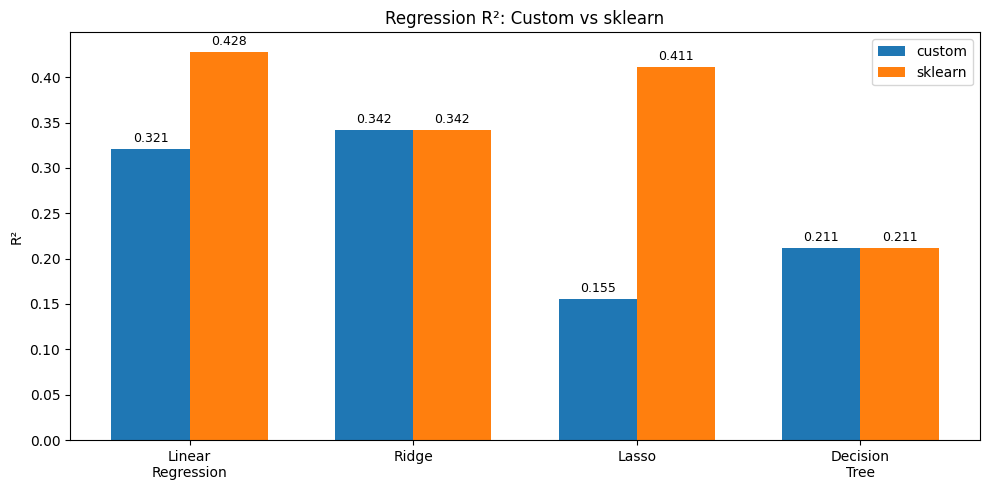

In [ ]:

pairs = [
    ("MyLinearRegression (GD)", "sklearn LinearRegression"),
    ("MyRidge (analytical)", "sklearn Ridge"),
    ("MyLasso (GD)", "sklearn Lasso"),
    ("MyDesisionTreeRegressor", "sklearn DecisionTreeRegressor"),
]
labels = ["Linear\nRegression", "Ridge", "Lasso", "Decision\nTree"]
df_reg = pd.DataFrame(reg_results)
my_vals = [df_reg.loc[df_reg["Model"] == a, "R2"].values[0] for a, _ in pairs]
sk_vals = [df_reg.loc[df_reg["Model"] == b, "R2"].values[0] for _, b in pairs]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_my = ax.bar(x - width/2, my_vals, width, label="custom")
bars_sk = ax.bar(x + width/2, sk_vals, width, label="sklearn")

ax.bar_label(bars_my, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(bars_sk, fmt="%.3f", padding=3, fontsize=9)

ax.set_ylabel("R2")
ax.set_title("Regression R2: Custom vs sklearn")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

# Сравнение алгоритмов классификации

<h3> для алгоритмов классификации был использован датасет в котором по 30 числовым признакам

необходимо предсказать является ли опухоль доброкачественной или нет

## Загрузка и разделение датасета на тренировочную и тестовую выборки

In [15]:
bc = load_breast_cancer()
Xc = bc.data
yc = bc.target

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc)

scaler_c = StandardScaler()
Xc_train_sc = scaler_c.fit_transform(Xc_train)
Xc_test_sc  = scaler_c.transform(Xc_test)

Xc_train_df = pd.DataFrame(Xc_train_sc)
Xc_test_df  = pd.DataFrame(Xc_test_sc)
yc_train_s  = pd.Series(yc_train)
yc_test_s   = pd.Series(yc_test)

## обучение всех регрессоров

In [ ]:
clf_results = []

def clf_row(name, y_true, y_pred):
    clf_results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Recall": recall_score(y_true, y_pred)
    })

# Logistic Regression
my_logreg = MyLogisticRegressionSGD(epochs=100, learning_rate=0.01)
my_logreg.fit(Xc_train_sc, yc_train)
clf_row("MyLogisticRegressionSGD", yc_test, my_logreg.predict(Xc_test_sc))

sk_logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(Xc_train_sc, yc_train)
clf_row("sklearn LogisticRegression", yc_test, sk_logreg.predict(Xc_test_sc))

# knn
my_knn = MyKNN(n_neighbors=5)
my_knn.fit(Xc_train_sc, yc_train)
clf_row("MyKNN (k=5)", yc_test, my_knn.predict(Xc_test_sc))

sk_knn = KNeighborsClassifier(n_neighbors=5).fit(Xc_train_sc, yc_train)
clf_row("sklearn KNeighborsClassifier", yc_test, sk_knn.predict(Xc_test_sc))

# Naive Bayes
my_nb = NB()
my_nb.fit(Xc_train_df, yc_train_s)
clf_row("NB (Gaussian)", yc_test, my_nb.predict(Xc_test_df))

sk_nb = GaussianNB().fit(Xc_train_sc, yc_train)
clf_row("sklearn GaussianNB", yc_test, sk_nb.predict(Xc_test_sc))

# Decision Tree Classifier
my_dtc = MyDesisionTreeClassifier(max_depth=4)
my_dtc.fit(Xc_train_sc, yc_train)
clf_row("MyDesisionTreeClassifier", yc_test, my_dtc.predict(Xc_test_sc))

sk_dtc = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE).fit(Xc_train_sc, yc_train)
clf_row("sklearn DecisionTreeClassifier", yc_test, sk_dtc.predict(Xc_test_sc))

# Random Forest
my_rf = MyRandomForestClassifier(n_estimators=50, max_depth=5, random_state=RANDOM_STATE)
my_rf.fit(Xc_train_sc, yc_train)
clf_row("MyRandomForestClassifier", yc_test, my_rf.predict(Xc_test_sc))

sk_rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=RANDOM_STATE).fit(Xc_train_sc, yc_train)
clf_row("sklearn RandomForestClassifier", yc_test, sk_rf.predict(Xc_test_sc))

# Gradient Boosting
my_gbdt = MyGBDTClassifier(n_estimators=50, max_depth=3, learning_rate=0.1)
my_gbdt.fit(Xc_train_sc, yc_train)
clf_row("MyGBDTClassifier", yc_test, my_gbdt.predict(Xc_test_sc))

sk_gbdt = GradientBoostingClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE).fit(Xc_train_sc, yc_train)
clf_row("sklearn GradientBoostingClassifier", yc_test, sk_gbdt.predict(Xc_test_sc))

# Extra Trees
my_et = ExtraTreesClassifier(n_estimators=50, max_depth=5)
my_et.fit(Xc_train_sc, yc_train)
clf_row("ExtraTreesClassifier", yc_test, my_et.predict(Xc_test_sc))

sk_et = SkExtraTreesClassifier(n_estimators=50, max_depth=5, random_state=RANDOM_STATE).fit(Xc_train_sc, yc_train)
clf_row("sklearn ExtraTreesClassifier", yc_test, sk_et.predict(Xc_test_sc))

pd.DataFrame(clf_results)

c:\Users\qa1ro\OneDrive\Рабочий стол\projects\ml-algs-implementation\src\supervised\naive_bayes\naive_bayes.py:32: RuntimeWarning: divide by zero encountered in log
  log_p1 = np.log(self.P_1) + np.sum(np.log(self._calc(X, self.E_1, std1)), axis=1)


,Model,Accuracy,Recall
0,MyLogisticRegressionSGD,0.9912,1.0000
1,sklearn LogisticRegression,0.9912,1.0000
2,MyKNN (k=5),0.9825,1.0000
3,sklearn KNeighborsClassifier,0.9825,1.0000
4,NB (Gaussian),0.9298,0.9306
5,sklearn GaussianNB,0.9298,0.9306
6,MyDesisionTreeClassifier,0.9211,0.9306
7,sklearn DecisionTreeClassifier,0.9123,0.9444
8,MyRandomForestClassifier,0.9386,0.9583
9,sklearn RandomForestClassifier,0.9474,0.9722


## визуализация

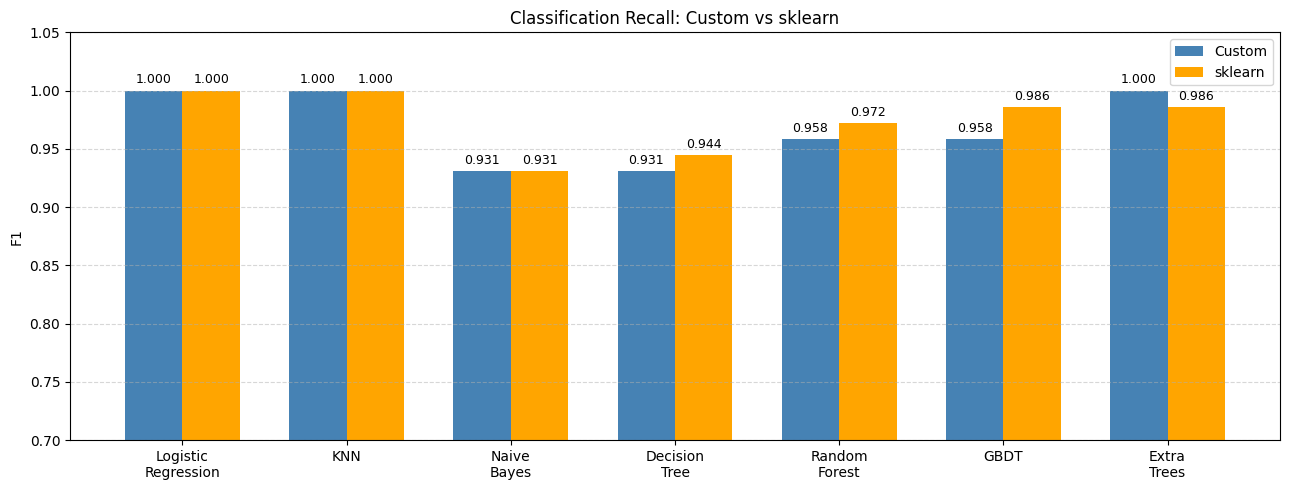

In [28]:
pairs_clf = [
    ("MyLogisticRegressionSGD", "sklearn LogisticRegression"),
    ("MyKNN (k=5)", "sklearn KNeighborsClassifier"),
    ("NB (Gaussian)", "sklearn GaussianNB"),
    ("MyDesisionTreeClassifier", "sklearn DecisionTreeClassifier"),
    ("MyRandomForestClassifier", "sklearn RandomForestClassifier"),
    ("MyGBDTClassifier", "sklearn GradientBoostingClassifier"),
    ("ExtraTreesClassifier", "sklearn ExtraTreesClassifier"),
]
labels_clf = ["Logistic\nRegression", "KNN", "Naive\nBayes", "Decision\nTree", "Random\nForest", "GBDT", "Extra\nTrees"]
df_clf  = pd.DataFrame(clf_results)
my_vals_clf = [df_clf.loc[df_clf["Model"] == a, "Recall"].values[0] for a, _ in pairs_clf]
sk_vals_clf = [df_clf.loc[df_clf["Model"] == b, "Recall"].values[0] for _, b in pairs_clf]

x     = np.arange(len(labels_clf))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars_my = ax.bar(x - width/2, my_vals_clf, width, label="Custom", color="steelblue")
bars_sk = ax.bar(x + width/2, sk_vals_clf, width, label="sklearn", color="orange")

ax.bar_label(bars_my, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(bars_sk, fmt="%.3f", padding=3, fontsize=9)

ax.set_ylabel("F1")
ax.set_title("Classification Recall: Custom vs sklearn")
ax.set_xticks(x)
ax.set_xticklabels(labels_clf)
ax.set_ylim(0.7, 1.05)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Проверка алгоритмов обучения без учителя

In [34]:
X_cluster, y_cluster = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=RANDOM_STATE)

In [66]:
km = KMeans(n_clusters=3, random_state=RANDOM_STATE)
predictions =  km.fit_predict(X_cluster)


In [62]:
silhouette_score(y_cluster.reshape(-1, 1), predictions.reshape(-1, 1))

c:\Users\qa1ro\OneDrive\Рабочий стол\projects\ml-algs-implementation\venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


1.0

In [68]:
mkm = MyKMeans(n_clusters=3)
my_predictions =  km.fit_predict(X_cluster)

In [69]:
silhouette_score(y_cluster.reshape(-1, 1), my_predictions.reshape(-1, 1))


c:\Users\qa1ro\OneDrive\Рабочий стол\projects\ml-algs-implementation\venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


1.0

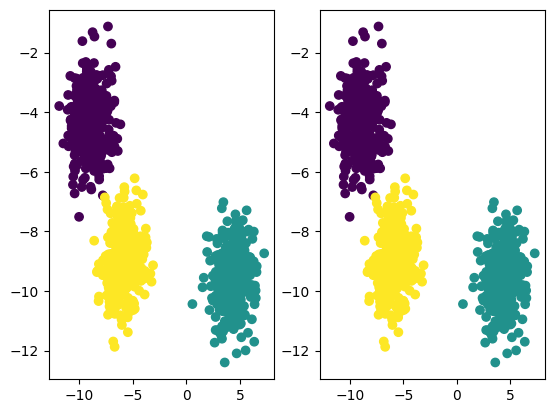

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 5))
ax1.scatter(X_cluster[:, 0], X_cluster[:, 1], c=predictions)
ax2.scatter(X_cluster[:, 0], X_cluster[:, 1], c=my_predictions)

c:\Users\qa1ro\OneDrive\Рабочий стол\projects\ml-algs-implementation\venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


1.0